## 將分類問題，loss的比較

將分類問題當成MSE的方式處理，跟使用機率的cross-entropy比較
但做不出我想像中的效果，這兩個方式並沒有明顯的差異，這是為什麼？

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons

%matplotlib inline

In [2]:
# 使用make_moons生成內外圈的二維分類資料集
from sklearn.datasets import make_moons, make_circles

# 生成內外圈的二維分類資料集
X_moons, y_moons = make_moons(n_samples=2000, noise=0.3, random_state=42)
#X_circles, y_circles = make_circles(n_samples=2000, noise=0.1, random_state=42, factor=0.5)

# 分割數據為70%訓練和30%測試
X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, test_size=0.3, random_state=42, stratify=y_moons)
print('Labels count in y:', np.bincount(y_moons))
print('Labels count in y_train:', np.bincount(y_train))
print('Labels count in y_test:', np.bincount(y_test))

Labels count in y: [1000 1000]
Labels count in y_train: [700 700]
Labels count in y_test: [300 300]


In [3]:
# 標準化特徵
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

print("訓練數據標準化後的統計:")
print(f"平均值: {np.mean(X_train_std, axis=0)}")
print(f"標準差: {np.std(X_train_std, axis=0)}")

訓練數據標準化後的統計:
平均值: [-7.64249775e-16  3.05886269e-16]
標準差: [1. 1.]


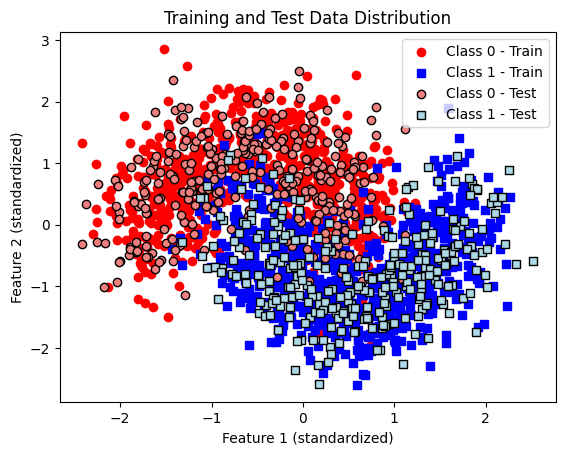

In [4]:
# 先把兩類的訓練集跟測試集畫出來
plt.scatter(X_train_std[y_train==0, 0], X_train_std[y_train==0, 1], color='red', marker='o', label='Class 0 - Train')
plt.scatter(X_train_std[y_train==1, 0], X_train_std[y_train==1, 1], color='blue', marker='s', label='Class 1 - Train')
plt.scatter(X_test_std[y_test==0, 0], X_test_std[y_test==0, 1], color='lightcoral', marker='o', edgecolor='black', label='Class 0 - Test')
plt.scatter(X_test_std[y_test==1, 0], X_test_std[y_test==1, 1], color='lightblue', marker='s', edgecolor='black', label='Class 1 - Test')
plt.xlabel('Feature 1 (standardized)')
plt.ylabel('Feature 2 (standardized)')
plt.title('Training and Test Data Distribution')
plt.legend()
plt.show()

In [5]:
class LogisticRegressionMSE:
    """使用MSE作為損失函數的邏輯回歸"""
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.costs = []

    def sigmoid(self, z):
        # 避免溢出
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        # 初始化權重
        n_samples, n_features = X.shape
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0
        
        # 梯度下降
        for i in range(self.n_iterations):
            # 前向傳播
            z = np.dot(X, self.weights) + self.bias
            #y_pred = self.sigmoid(z)
            y_pred = z
            
            # MSE損失
            cost = np.mean((y_pred - y) ** 2)
            self.costs.append(cost)
            
            # 計算梯度
            dw = (2/n_samples) * np.dot(X.T, (y_pred - y))
            db = (2/n_samples) * np.sum(y_pred - y)
            
            # 更新權重
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
    
    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        #z = self.sigmoid(z)
        return z
    
    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

class LogisticRegressionCrossEntropy:
    """使用Cross-Entropy作為損失函數的邏輯回歸"""
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.costs = []
    
    def sigmoid(self, z):
        # 避免溢出
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        # 初始化權重
        n_samples, n_features = X.shape
        # weights初始化為小隨機值以打破對稱性
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0
        
        # 梯度下降
        for i in range(self.n_iterations):
            # 前向傳播
            z = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(z)
            
            # Cross-Entropy損失
            # 避免log(0)
            y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
            cost = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
            self.costs.append(cost)
            
            # 計算梯度
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)
            
            # 更新權重
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
    
    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)
    
    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

In [6]:
# 訓練兩個模型
n_iterations = 10
lr_mse = LogisticRegressionMSE(learning_rate=0.1, n_iterations=n_iterations)
lr_ce = LogisticRegressionCrossEntropy(learning_rate=0.1, n_iterations=n_iterations)

# 訓練模型
lr_mse.fit(X_train_std, y_train)
lr_ce.fit(X_train_std, y_train)

# 預測和評估
y_pred_mse = lr_mse.predict(X_test_std)
y_pred_ce = lr_ce.predict(X_test_std)

print("MSE Loss 模型準確率:", accuracy_score(y_test, y_pred_mse))
print("Cross-Entropy Loss 模型準確率:", accuracy_score(y_test, y_pred_ce))

MSE Loss 模型準確率: 0.86
Cross-Entropy Loss 模型準確率: 0.87


In [7]:
# 創建損失函數的3D可視化
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def mse_loss(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

def cross_entropy_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 創建特徵空間的網格
feature1_range = np.linspace(X_train_std[:, 0].min() - 1, X_train_std[:, 0].max() + 1, 30)
feature2_range = np.linspace(X_train_std[:, 1].min() - 1, X_train_std[:, 1].max() + 1, 30)
F1, F2 = np.meshgrid(feature1_range, feature2_range)

# 計算每個點的損失值
mse_losses = np.zeros(F1.shape)
ce_losses = np.zeros(F1.shape)

for i in range(F1.shape[0]):
    for j in range(F1.shape[1]):
        # 創建測試點
        test_point = np.array([[F1[i, j], F2[i, j]]])
        
        # 使用訓練好的模型預測
        prob_mse = lr_mse.predict_proba(test_point)[0]
        prob_ce = lr_ce.predict_proba(test_point)[0]
        
        # 計算該點對所有訓練數據的平均損失
        mse_loss_val = 0
        ce_loss_val = 0
        
        for k in range(len(y_train)):
            mse_loss_val += (prob_mse - y_train[k]) ** 2
            ce_loss_val += -(y_train[k] * np.log(np.clip(prob_ce, 1e-15, 1-1e-15)) + 
                           (1 - y_train[k]) * np.log(np.clip(1 - prob_ce, 1e-15, 1-1e-15)))
        
        mse_losses[i, j] = mse_loss_val / len(y_train)
        ce_losses[i, j] = ce_loss_val / len(y_train)

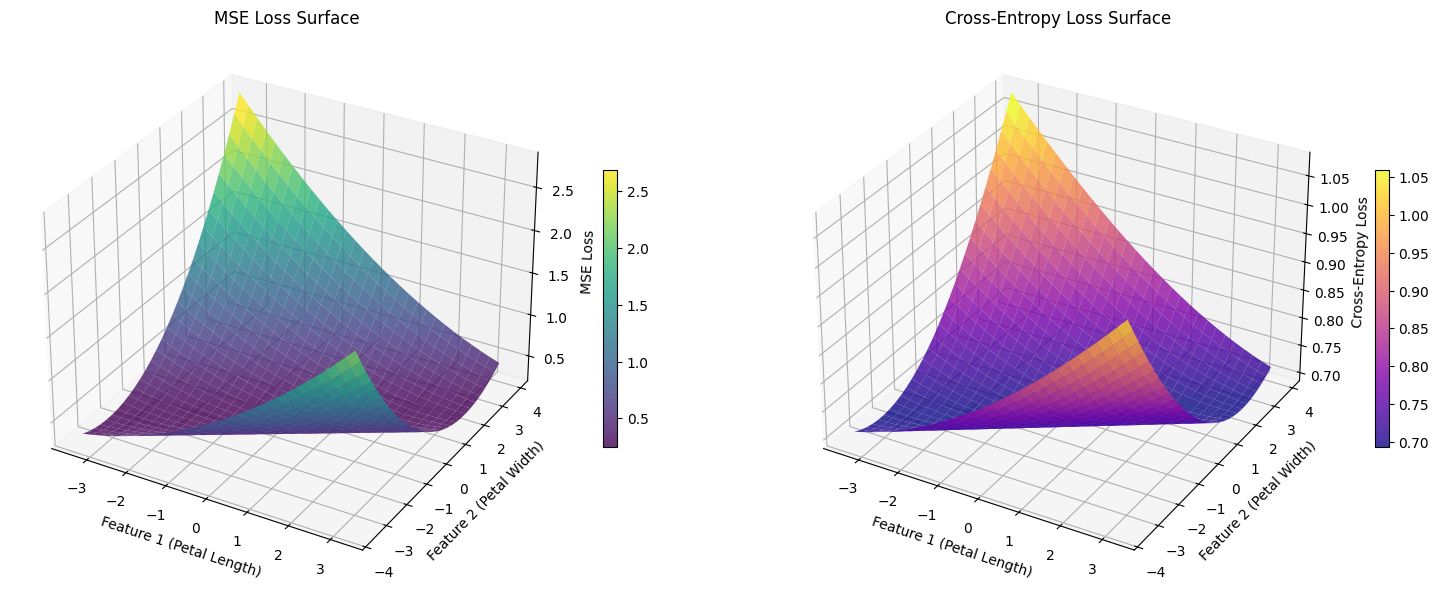

In [8]:
# 創建3D圖形
fig = plt.figure(figsize=(16, 6))

# MSE Loss 3D 圖
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(F1, F2, mse_losses, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Feature 1 (Petal Length)')
ax1.set_ylabel('Feature 2 (Petal Width)')
ax1.set_zlabel('MSE Loss')
ax1.set_title('MSE Loss Surface')
fig.colorbar(surf1, ax=ax1, shrink=0.5)

# Cross-Entropy Loss 3D 圖
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(F1, F2, ce_losses, cmap='plasma', alpha=0.8)
ax2.set_xlabel('Feature 1 (Petal Length)')
ax2.set_ylabel('Feature 2 (Petal Width)')
ax2.set_zlabel('Cross-Entropy Loss')
ax2.set_title('Cross-Entropy Loss Surface')
fig.colorbar(surf2, ax=ax2, shrink=0.5)

plt.tight_layout()
plt.show()

MSE 梯度大小範圍: min=4.1692e-04, max=9.6571e-01
CE  梯度大小範圍: min=1.4190e-05, max=1.3356e-01


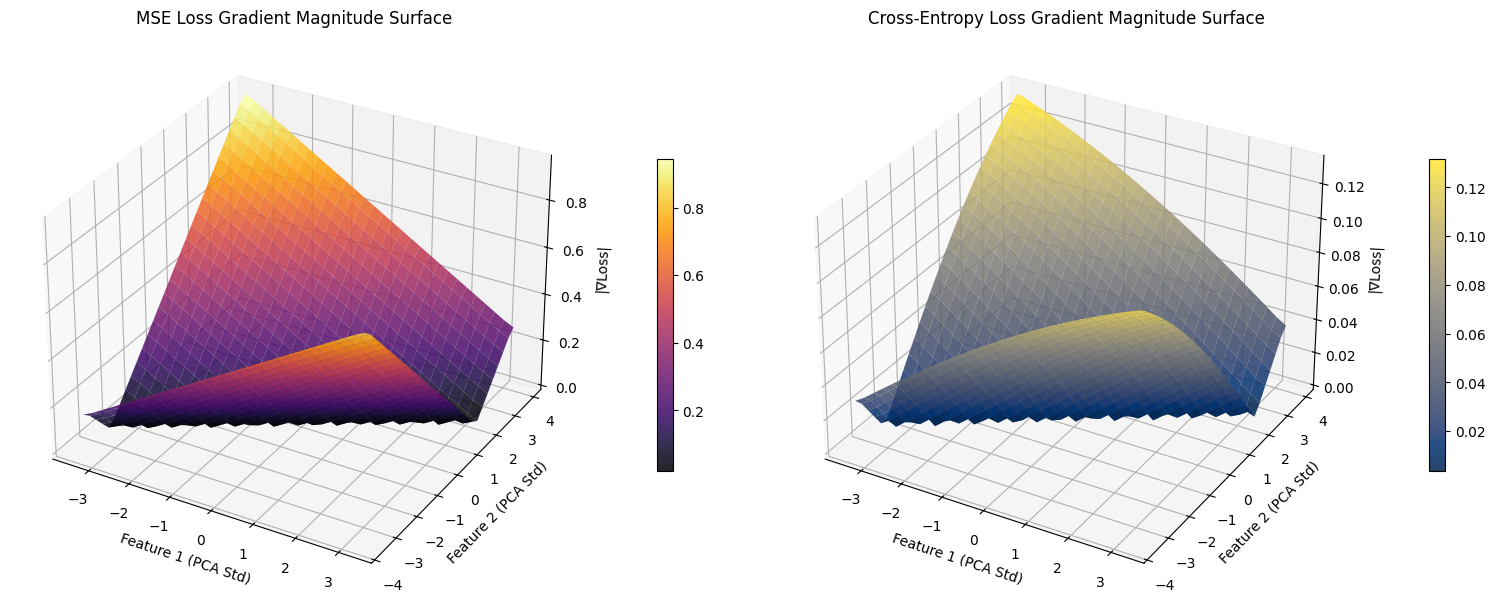

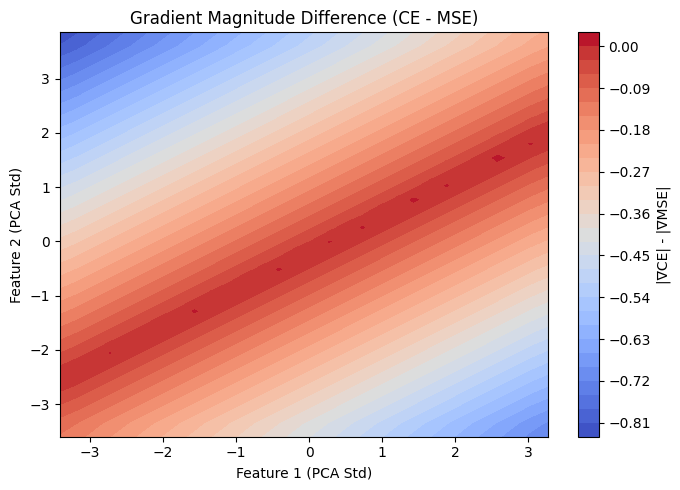

In [9]:
# 3D 梯度大小曲面比較 (MSE vs Cross-Entropy)

# 使用已計算的 mse_losses, ce_losses 與網格 F1, F2
# 如果在獨立執行此 cell 時變數不存在，可提示重新執行前面格子
required_vars = ['mse_losses', 'ce_losses', 'F1', 'F2', 'feature1_range', 'feature2_range']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"缺少變數: {missing}，請先執行前面計算 loss surface 的格子。")

# 計算數值梯度 (np.gradient 參數順序: axis0 對應 F2 / feature2_range, axis1 對應 F1 / feature1_range)
dy2_mse, dy1_mse = np.gradient(mse_losses,
                               feature2_range[1]-feature2_range[0],
                               feature1_range[1]-feature1_range[0])
dy2_ce, dy1_ce = np.gradient(ce_losses,
                             feature2_range[1]-feature2_range[0],
                             feature1_range[1]-feature1_range[0])

# 梯度向量大小 (L2 norm)
grad_mag_mse = np.sqrt(dy1_mse**2 + dy2_mse**2)
grad_mag_ce  = np.sqrt(dy1_ce**2 + dy2_ce**2)

# 避免極端值影響可視化，可選擇性裁剪 (此處保留原始值)
print(f"MSE 梯度大小範圍: min={grad_mag_mse.min():.4e}, max={grad_mag_mse.max():.4e}")
print(f"CE  梯度大小範圍: min={grad_mag_ce.min():.4e}, max={grad_mag_ce.max():.4e}")

fig = plt.figure(figsize=(16,6))

ax1 = fig.add_subplot(121, projection='3d')
surf_g1 = ax1.plot_surface(F1, F2, grad_mag_mse, cmap='inferno', alpha=0.85, linewidth=0, antialiased=True)
ax1.set_title('MSE Loss Gradient Magnitude Surface')
ax1.set_xlabel('Feature 1 (PCA Std)')
ax1.set_ylabel('Feature 2 (PCA Std)')
ax1.set_zlabel('|∇Loss|')
fig.colorbar(surf_g1, ax=ax1, shrink=0.55, pad=0.1)

ax2 = fig.add_subplot(122, projection='3d')
surf_g2 = ax2.plot_surface(F1, F2, grad_mag_ce, cmap='cividis', alpha=0.85, linewidth=0, antialiased=True)
ax2.set_title('Cross-Entropy Loss Gradient Magnitude Surface')
ax2.set_xlabel('Feature 1 (PCA Std)')
ax2.set_ylabel('Feature 2 (PCA Std)')
ax2.set_zlabel('|∇Loss|')
fig.colorbar(surf_g2, ax=ax2, shrink=0.55, pad=0.1)

plt.tight_layout()
plt.show()

# (可選) 對比兩者差值
plt.figure(figsize=(7,5))
diff = grad_mag_ce - grad_mag_mse
plt.contourf(F1, F2, diff, levels=30, cmap='coolwarm')
plt.colorbar(label='|∇CE| - |∇MSE|')
plt.title('Gradient Magnitude Difference (CE - MSE)')
plt.xlabel('Feature 1 (PCA Std)')
plt.ylabel('Feature 2 (PCA Std)')
plt.tight_layout()
plt.show()

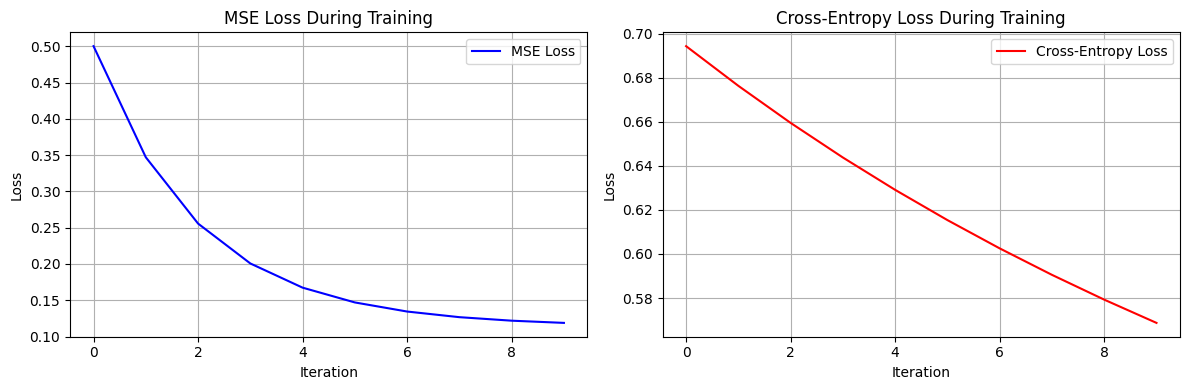

In [10]:
# 比較訓練過程中的損失變化
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(lr_mse.costs, label='MSE Loss', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MSE Loss During Training')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lr_ce.costs, label='Cross-Entropy Loss', color='red')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Cross-Entropy Loss During Training')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

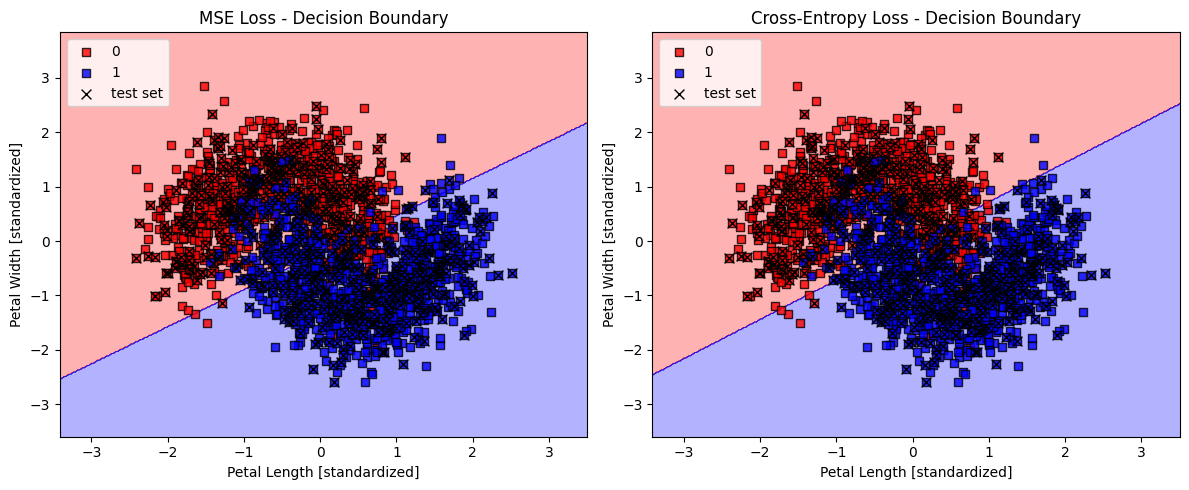

In [11]:
# 繪製決策邊界比較
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    # 設置標記和顏色
    markers = ('s', 's', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    
    # 繪製決策面
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                          np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    
    # 繪製所有樣本
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                   alpha=0.8, c=colors[idx],
                   marker=markers[idx], label=cl, edgecolor='black')
    
    # 突出顯示測試樣本
    if test_idx:
        X_test, y_test = X[test_idx, :], y[test_idx]
        plt.scatter(X_test[:, 0], X_test[:, 1],
                   c='black', alpha=1.0, linewidths=1,
                   marker='x', s=50, label='test set')

# 合併訓練和測試數據來繪製完整圖像
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_regions(X_combined_std, y_combined, lr_mse, 
                     test_idx=range(len(y_train), len(y_train) + len(y_test)))
plt.xlabel('Petal Length [standardized]')
plt.ylabel('Petal Width [standardized]')
plt.title('MSE Loss - Decision Boundary')
plt.legend(loc='upper left')

plt.subplot(1, 2, 2)
plot_decision_regions(X_combined_std, y_combined, lr_ce,
                     test_idx=range(len(y_train), len(y_train) + len(y_test)))
plt.xlabel('Petal Length [standardized]')
plt.ylabel('Petal Width [standardized]')
plt.title('Cross-Entropy Loss - Decision Boundary')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [12]:
# 印出模型參數比较
print("模型參數比較:")
print("=" * 50)
print("MSE Loss 模型:")
print(f"  權重: {lr_mse.weights}")
print(f"  偏置: {lr_mse.bias}")
print(f"  最終損失: {lr_mse.costs[-1]:.6f}")

print("\nCross-Entropy Loss 模型:")
print(f"  權重: {lr_ce.weights}")
print(f"  偏置: {lr_ce.bias}")
print(f"  最終損失: {lr_ce.costs[-1]:.6f}")

print("\n性能比較:")
print("=" * 50)
print(f"MSE Loss 模型準確率: {accuracy_score(y_test, y_pred_mse):.4f}")
print(f"Cross-Entropy Loss 模型準確率: {accuracy_score(y_test, y_pred_ce):.4f}")

模型參數比較:
MSE Loss 模型:
  權重: [ 0.17183258 -0.25198177]
  偏置: 0.4463129088000002
  最終損失: 0.118841

Cross-Entropy Loss 模型:
  權重: [ 0.21470636 -0.29781583]
  偏置: -7.229640780055391e-07
  最終損失: 0.568701

性能比較:
MSE Loss 模型準確率: 0.8600
Cross-Entropy Loss 模型準確率: 0.8700
